# WEEE — MUSE EEG: Aktivite, MET, Enerji Harcaması

Drive bağlantısı


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Kurulum + ayarlar (pencere 60s/%50, HSI eşiği, 50Hz notch). tüm analizde ortak sabitler.

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import glob, os, re, shutil, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt, iirnotch
from scipy.stats import spearmanr

cand = glob.glob('/content/weee_data/**/Study_Information.csv', recursive=True)
if not cand:
    zips = glob.glob('/content/drive/MyDrive/PAWS/*.zip')
    if zips:
        shutil.unpack_archive(zips[0], '/content/weee_data')
        cand = glob.glob('/content/weee_data/**/Study_Information.csv', recursive=True)
DATA_ROOT = os.path.dirname(cand[0]); print("DATA_ROOT =", DATA_ROOT)

WIN         = 60
OVERLAP     = 0.5
CLEAN_ONLY  = False
HSI_MIN_GOOD= 0.5
MAX_OFF     = 300
EEG_MAINS   = 50.0
FS=256.0; BAND_FS=10.0
EEG_CH=['TP9','AF7','AF8','TP10']
FRONTAL=['AF7','AF8']; TEMPORAL=['TP9','TP10']
BANDS={'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,44)}
print(f"WIN={WIN}s OVERLAP={OVERLAP} CLEAN_ONLY={CLEAN_ONLY} | kanallar={EEG_CH}")

DATA_ROOT = /content/weee_data/dataset
WIN=60s OVERLAP=0.5 CLEAN_ONLY=False | kanallar=['TP9', 'AF7', 'AF8', 'TP10']


Aktivite aralıkları + MET etiketleri. EEG'yi 6 aktivite penceresine bölüp hedef (MET) atamak; protokol 5 dk/aktivite, UTC hizalama.

In [ ]:
ACTS=[('Sit','Start_Sit','MET_Sit'),('Stand','Start_Stand','MET_Stand'),
      ('Cycle1','Start_Cycle1','MET_Cycle1'),('Cycle2','Start_Cycle2','MET_Cycle2'),
      ('Run1','Start_Run1','MET_Run1'),('Run2','Start_Run2','MET_Run2')]
ACT_ORDER=[a for a,_,_ in ACTS]
COARSE={'Sit':'rest','Stand':'rest','Cycle1':'cycle','Cycle2':'cycle','Run1':'run','Run2':'run'}
def to_unix(s): return pd.Timestamp(str(s).strip()).tz_localize('UTC').timestamp()
def to_num(x):
    try: return float(str(x).strip())
    except: return np.nan
def activity_segments(r):
    st=[to_unix(r[c]) for _,c,_ in ACTS]; out=[]
    for i,(nm,sc,mc) in enumerate(ACTS):
        a=st[i]; nxt=st[i+1] if i+1<len(st) else a+300; b=min(nxt,a+300)
        out.append(dict(activity=nm,MET=to_num(r[mc]),start=a,end=b,valid=b>a))
    return out
SI=pd.read_csv(os.path.join(DATA_ROOT,'Study_Information.csv'))
print("özne sayısı:",len(SI))

özne sayısı: 17


MUSE okuyucular (ham EEG 256Hz, band güçleri Bels, HSI). MindMonitor dosyalarını + kanal kalite bilgisini almak.

In [ ]:
def muse_folder(pid):
    for fold in glob.glob(os.path.join(DATA_ROOT,'*','MUSE')):
        if 'P%02d'%int(''.join(filter(str.isdigit,fold.split(os.sep)[-2])))==pid: return fold
    return None
def _read(path):
    d=pd.read_csv(path,header=None); return d.sort_values(0).reset_index(drop=True)
def load_raw(fold):
    p=os.path.join(fold,'eeg.csv')
    if not os.path.exists(p): return None,None
    e=_read(p); t=e.iloc[:,0].values
    ch={c:e.iloc[:,i+1].values for i,c in enumerate(EEG_CH) if i+1<e.shape[1]}
    return t,ch
def load_band(fold,name):
    p=os.path.join(fold,f'{name}_absolute.csv')
    if not os.path.exists(p): return None,None
    b=_read(p); t=b.iloc[:,0].values
    ch={c:b.iloc[:,i+1].replace(0.0,np.nan).values for i,c in enumerate(EEG_CH) if i+1<b.shape[1]}
    return t,ch
def load_hsi(fold):
    p=os.path.join(fold,'horseshoe.csv')
    if not os.path.exists(p): return None,None
    h=_read(p); t=h.iloc[:,0].values
    ch={c:h.iloc[:,i+1].values for i,c in enumerate(EEG_CH) if i+1<h.shape[1]}
    return t,ch
def load_marker(fold,name):
    p=os.path.join(fold,f'{name}.csv')
    if not os.path.exists(p): return np.array([])
    try: return _read(p).iloc[:,0].values
    except Exception: return np.array([])
print("okuyucular hazır")

okuyucular hazır


Frekans özellikleri: bandpower(rölatif), spectral centroid/spread/entropy, edge95, Hjorth, band oranları. her pencereyi sayısallaştırmak.

In [ ]:
def clean_zeros(x):
    return pd.Series(x,dtype=float).replace(0.0,np.nan).interpolate(limit_direction='both').to_numpy()
def preprocess_full(x,fs=FS):
    x=clean_zeros(x)
    if not np.isfinite(x).all() or np.nanstd(x)<1e-6: return None
    try:
        bn,an=iirnotch(EEG_MAINS,30.0,fs); x=filtfilt(bn,an,x)
        b,a=butter(4,[1/(fs/2), 40/(fs/2)],btype='band'); x=filtfilt(b,a,x)
    except Exception: return None
    return x
def hjorth(x):
    dx=np.diff(x); ddx=np.diff(dx); v0=np.var(x)+1e-12; v1=np.var(dx)+1e-12; v2=np.var(ddx)+1e-12
    mob=np.sqrt(v1/v0); return float(mob), float(np.sqrt(v2/v1)/mob)
def raw_feats(w,fs=FS):
    if w is None or len(w)<fs*2: return {}
    f,P=welch(w,fs=fs,nperseg=int(min(512,len(w)))); tot=P.sum()+1e-12; rel={}; o={}
    for nm,(lo,hi) in BANDS.items():
        rel[nm]=float(P[(f>=lo)&(f<hi)].sum()/tot); o['rel_'+nm]=rel[nm]
    c=float((f*P).sum()/tot); o['centroid']=c
    o['spread']=float(np.sqrt(((f-c)**2*P).sum()/tot))
    pn=P/tot; o['spec_entropy']=float(-(pn*np.log2(pn+1e-12)).sum())
    cum=np.cumsum(P)/tot; o['edge95']=float(f[min(np.searchsorted(cum,0.95),len(f)-1)])
    mob,comp=hjorth(w); o['hj_mob']=mob; o['hj_comp']=comp
    o['engagement']=float(rel['beta']/(rel['alpha']+rel['theta']+1e-9))
    o['DAR']=float(rel['delta']/(rel['alpha']+1e-9))
    o['DTABR']=float((rel['delta']+rel['theta'])/(rel['alpha']+rel['beta']+1e-9))
    return o
def pdbsi(vals):
    a=np.array(vals.get('AF7',[np.nan]*5)); b=np.array(vals.get('AF8',[np.nan]*5))
    d=np.abs(a-b)/(np.abs(a)+np.abs(b)+1e-9)
    return float(np.nanmean(d)) if np.isfinite(d).any() else np.nan
print("özellik fonksiyonları hazır")

özellik fonksiyonları hazır


Özne özellik tablosu + HSI artefakt kapısı. pencere başına özellik matrisi, kötü-kontak pencereleri ayıklama seçeneği.

In [ ]:
_MUSE={}
def get_muse(pid):
    if pid in _MUSE: return _MUSE[pid]
    fold=muse_folder(pid)
    if fold is None: _MUSE[pid]=None; return None
    tr,raw=load_raw(fold)
    if tr is None: _MUSE[pid]=None; return None
    prep={c:preprocess_full(raw[c]) for c in raw}
    bands={nm:load_band(fold,nm) for nm in BANDS}
    th,hsi=load_hsi(fold)
    mk={m:load_marker(fold,m) for m in ('blink','jaw_clench')}
    _MUSE[pid]=dict(tr=tr,prep=prep,bands=bands,th=th,hsi=hsi,mk=mk); return _MUSE[pid]

def _win_bounds(tr,a,b):
    m=(tr>=a)&(tr<b); idx=np.where(m)[0]; w=int(WIN*FS); step=max(1,int(w*(1-OVERLAP)))
    return [idx[s:s+w] for s in range(0,len(idx)-w+1,step)]

def build_eeg_table(clean_only=None):
    clean_only=CLEAN_ONLY if clean_only is None else clean_only
    rows=[]
    for _,r in SI.iterrows():
        pid=r['Participant']; D=get_muse(pid)
        if D is None: continue
        tr,prep,bands,th,hsi,mk=D['tr'],D['prep'],D['bands'],D['th'],D['hsi'],D['mk']
        for s in activity_segments(r):
            if not s['valid']: continue
            for sl in _win_bounds(tr,s['start'],s['end']):
                if len(sl)<FS*2: continue
                t0,t1=tr[sl[0]],tr[sl[-1]]; feat={}
                for ch in EEG_CH:
                    fw=prep[ch][sl] if prep.get(ch) is not None else None
                    for k,v in raw_feats(fw).items(): feat[f'{ch}_{k}']=v
                bandvals={}
                for nm,(tb,cb) in bands.items():
                    if tb is None: continue
                    bm=(tb>=t0)&(tb<t1)
                    for ch in EEG_CH:
                        val=np.nanmean(cb[ch][bm]) if (ch in cb and bm.any()) else np.nan
                        feat[f'{ch}_bel_{nm}']=val
                        bandvals.setdefault(ch,{})[nm]=val
                a7=feat.get('AF7_bel_alpha',np.nan); a8=feat.get('AF8_bel_alpha',np.nan)
                feat['FAA']=float(a8-a7) if (a7==a7 and a8==a8) else np.nan
                feat['pdBSI_frontal']=pdbsi({ch:[bandvals.get(ch,{}).get(nm,np.nan) for nm in BANDS] for ch in FRONTAL})
                fr_good=1.0
                if th is not None:
                    hm=(th>=t0)&(th<t1)
                    for ch in EEG_CH:
                        feat[f'{ch}_hsi_good']=float(np.mean(hsi[ch][hm]==1.0)) if (ch in hsi and hm.any()) else 0.0
                    fr_good=np.nanmean([feat.get(f'{c}_hsi_good',0.0) for c in FRONTAL])
                feat['frontal_hsi_good']=float(fr_good)
                for m in ('blink','jaw_clench'):
                    feat[f'{m}_n']=int(((mk[m]>=t0)&(mk[m]<t1)).sum()) if mk[m].size else 0
                if clean_only and fr_good<HSI_MIN_GOOD: continue
                feat.update(MET=s['MET'],activity=s['activity'],coarse=COARSE[s['activity']],subject=pid)
                rows.append(feat)
    T=pd.DataFrame(rows)
    fcols=[c for c in T.columns if c not in {'MET','EE','activity','coarse','subject'}]
    T[fcols]=T[fcols].replace([np.inf,-np.inf],np.nan)
    return T,fcols
print("tablo kurucu hazır")

tablo kurucu hazır


Tabloyu kurulumu + ön kontrol.
özne/pencere/eksik sayılarını doğrulamak.

In [ ]:
t0=time.time()
T,FCOLS=build_eeg_table()
_allnan=[c for c in FCOLS if T[c].isna().all()]
if _allnan:
    T=T.drop(columns=_allnan); FCOLS=[c for c in FCOLS if c not in _allnan]
    print("tamamen boş (hiç iyi kanalı olmayan) sütun düşürüldü:",_allnan)
print(f"tablo: {T.shape[0]} pencere × {len(FCOLS)} özellik | özne {T['subject'].nunique()} | {time.time()-t0:.0f} sn")
print("\nözne × pencere:"); print(T.groupby('subject').size().to_string())
print("\naktivite × pencere:"); print(T.groupby('activity').size().reindex(ACT_ORDER).to_string())
na=T[FCOLS].isna().mean().sort_values(ascending=False)
print(f"\nen çok eksik özellik (yapısal, imputation ile doldurulacak):"); print((na[na>0].head(8)*100).round(1).astype(str).add(' %').to_string())
print("\nHSI frontal iyi-oranı (aktivite ort.) — düşükse hareket artefaktı riski yüksek:")
print(T.groupby('activity')['frontal_hsi_good'].mean().reindex(ACT_ORDER).round(2).to_string())

tablo: 615 pencere × 85 özellik | özne 16 | 39 sn

özne × pencere:
subject
P01    41
P03    40
P04     8
P05    48
P06    31
P07    46
P08    48
P09    47
P10    32
P11    47
P12    37
P13    49
P14     8
P15    51
P16    47
P17    35

aktivite × pencere:
activity
Sit       119
Stand     106
Cycle1    104
Cycle2    104
Run1       92
Run2       90

en çok eksik özellik (yapısal, imputation ile doldurulacak):
TP9_bel_alpha     46.5 %
TP9_bel_beta      46.5 %
TP10_bel_alpha    46.5 %
TP10_bel_theta    46.5 %
TP9_bel_gamma     46.5 %
TP10_bel_beta     46.5 %
TP10_bel_gamma    46.5 %
TP10_bel_delta    46.5 %

HSI frontal iyi-oranı (aktivite ort.) — düşükse hareket artefaktı riski yüksek:
activity
Sit       0.92
Stand     0.98
Cycle1    0.99
Cycle2    0.97
Run1      0.85
Run2      0.81


Modelleme çekirdeği: LOSO-CV + segment metrikler + model havuzu. özneler-arası genelleme; ivme notebook'uyla birebir kıyas.

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, confusion_matrix)
try:
    from xgboost import XGBRegressor; HAS_XGB=True
except Exception:
    HAS_XGB=False
IMP=lambda: SimpleImputer(strategy='median')
def model_zoo(n=0):
    z={'Linear(Ridge)'   : lambda: make_pipeline(IMP(),StandardScaler(),Ridge(alpha=1.0)),
       'RandomForest'    : lambda: make_pipeline(IMP(),RandomForestRegressor(n_estimators=300,random_state=0,n_jobs=-1)),
       'GradientBoosting': lambda: HistGradientBoostingRegressor(max_iter=400,max_depth=5,learning_rate=0.05,random_state=0)}
    if HAS_XGB:
        z['XGBoost']=lambda: XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,
                             subsample=0.9,colsample_bytree=0.9,random_state=0,n_jobs=-1)
    if 0<n<=6000:
        z['ANN(MLP)']=lambda: make_pipeline(IMP(),StandardScaler(),
                        MLPRegressor(hidden_layer_sizes=(64,32),max_iter=600,early_stopping=True,random_state=0))
        z['SVR(RBF)']=lambda: make_pipeline(IMP(),StandardScaler(),SVR(C=10,gamma='scale',epsilon=0.1))
    return z
def CLF(): return make_pipeline(IMP(),RandomForestClassifier(n_estimators=300,random_state=0,n_jobs=-1))
META={'MET','EE','activity','coarse','subject'}
def feat_cols(d,extra=()): return [c for c in d.columns if c not in META and pd.api.types.is_numeric_dtype(d[c])]+list(extra)
def smape(y,p):
    y=np.asarray(y,float); p=np.asarray(p,float)
    return float(np.mean(2*np.abs(p-y)/(np.abs(y)+np.abs(p)+1e-12))*100)
def seg_frame(sub,act,y,pred):
    d=pd.DataFrame({'subject':np.asarray(sub),'activity':np.asarray(act),
                    'y':np.asarray(y,float),'p':np.asarray(pred,float)}).dropna()
    return d.groupby(['subject','activity']).agg(y=('y','first'),p=('p','mean')).reset_index(),d
def seg_metrics(sub,act,y,pred,base=None):
    seg,d=seg_frame(sub,act,y,pred); yy,pp=seg['y'].values,seg['p'].values
    bb=np.full_like(yy,d['y'].mean()) if base is None else seg_frame(sub,act,y,base)[0]['p'].values
    return dict(MAE=mean_absolute_error(yy,pp),RMSE=mean_squared_error(yy,pp)**0.5,R2=r2_score(yy,pp),
                Spearman=spearmanr(pp,yy)[0],SMAPE=smape(yy,pp),MAE_base=mean_absolute_error(yy,bb),
                n=len(seg),subj=d['subject'].nunique())
def _prep(d,target,extra):
    need=[target]+list(extra); return d.dropna(subset=need).reset_index(drop=True)
def loso_single(d,target,fn,extra=(),return_pred=False):
    d=_prep(d,target,extra); cols=feat_cols(d,extra); y=d[target].values; yh=np.full(len(d),np.nan)
    for tr,te in LeaveOneGroupOut().split(d[cols],y,d['subject']):
        m=fn(); m.fit(d[cols].iloc[tr],y[tr]); yh[te]=m.predict(d[cols].iloc[te])
    ov=seg_metrics(d['subject'],d['activity'],y,yh)
    return (ov,d,yh) if return_pred else ov
def bootstrap_ci(seg,B=2000,seed=0):
    rng=np.random.default_rng(seed); g={s:x[['y','p']].values for s,x in seg.groupby('subject')}; k=list(g); v=[]
    for _ in range(B):
        arr=np.vstack([g[i] for i in rng.choice(k,len(k),replace=True)]); v.append(np.mean(np.abs(arr[:,1]-arr[:,0])))
    return float(np.percentile(v,2.5)),float(np.percentile(v,97.5))
def R(tag,ov,**kw): return dict(**kw,model=tag,**{k:round(ov[k],3) for k in ['MAE','RMSE','R2','Spearman','SMAPE']},MAE_base=round(ov['MAE_base'],3),n=ov['n'],subj=ov['subj'])
def run_reg(d,target,zoo_filter=None,extra=()):
    d2=_prep(d,target,extra); zoo=model_zoo(len(d2))
    if zoo_filter: zoo={k:v for k,v in zoo.items() if k in zoo_filter}
    return pd.DataFrame([R(nm,loso_single(d,target,fn,extra)) for nm,fn in zoo.items()]).sort_values('MAE')
COLS=['model','MAE','RMSE','R2','Spearman','SMAPE','MAE_base','n','subj']
print("çekirdek hazır | XGBoost:",HAS_XGB)

çekirdek hazır | XGBoost: True


Adım 1: aktivite sınıflandırma (LOSO RF, 6-sınıf + kaba 3-sınıf). Neden: EEG'den aktivite ayrılıyor mu?

In [ ]:
def loso_classify(d,label='activity'):
    cols=feat_cols(d); y=d[label].values; yh=np.empty(len(d),dtype=object)
    for tr,te in LeaveOneGroupOut().split(d[cols],y,d['subject']):
        c=CLF(); c.fit(d[cols].iloc[tr],y[tr]); yh[te]=c.predict(d[cols].iloc[te])
    win_acc=accuracy_score(y,yh); win_f1=f1_score(y,yh,average='macro')
    seg=pd.DataFrame({'subject':d['subject'],'activity':d['activity'],'true':d[label],'pred':yh})
    mv=seg.groupby(['subject','activity']).agg(true=('true','first'),
            pred=('pred',lambda s:s.value_counts().index[0])).reset_index()
    return dict(win_acc=win_acc,win_f1=win_f1,
                seg_acc=accuracy_score(mv['true'],mv['pred']),
                seg_f1=f1_score(mv['true'],mv['pred'],average='macro')), y, yh
for lab in ['activity','coarse']:
    m,y,yh=loso_classify(T,lab)
    k=T[lab].nunique()
    print(f"[{lab}] {k} sınıf (şans={1/k:.2f}) | pencere acc {m['win_acc']:.3f} F1 {m['win_f1']:.3f} "
          f"| segment-oyu acc {m['seg_acc']:.3f} F1 {m['seg_f1']:.3f}")
m,y,yh=loso_classify(T,'activity')
cm=confusion_matrix(y,yh,labels=ACT_ORDER)
print("\nkarışıklık matrisi (satır=gerçek, sütun=tahmin):")
print(pd.DataFrame(cm,index=ACT_ORDER,columns=ACT_ORDER).to_string())

[activity] 6 sınıf (şans=0.17) | pencere acc 0.392 F1 0.394 | segment-oyu acc 0.415 F1 0.408
[coarse] 3 sınıf (şans=0.33) | pencere acc 0.722 F1 0.725 | segment-oyu acc 0.805 F1 0.807

karışıklık matrisi (satır=gerçek, sütun=tahmin):
        Sit  Stand  Cycle1  Cycle2  Run1  Run2
Sit      42     44      13      14     1     5
Stand    48     25      15      16     0     2
Cycle1   15     17      38      26     3     5
Cycle2    4      4      21      40    13    22
Run1      0      1       3      12    44    32
Run2      0      0       1      11    26    52


→ şekil: karışıklık matrisi

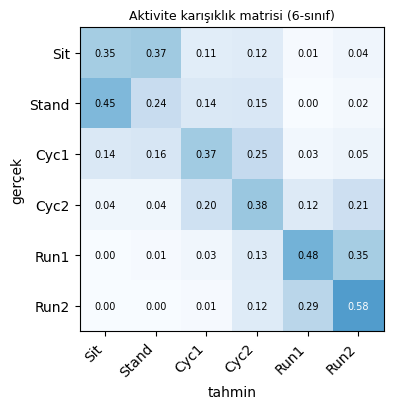

In [ ]:
import matplotlib.pyplot as plt, numpy as np
cm=np.array([[42,44,13,14,1,5],[48,25,15,16,0,2],[15,17,38,26,3,5],[4,4,21,40,13,22],[0,1,3,12,44,32],[0,0,1,11,26,52]])
labs=['Sit','Stand','Cyc1','Cyc2','Run1','Run2']; cmn=cm/cm.sum(1,keepdims=True)
fig,ax=plt.subplots(figsize=(4.6,4.2)); ax.imshow(cmn,cmap='Blues',vmin=0,vmax=1)
ax.set_xticks(range(6)); ax.set_xticklabels(labs,rotation=45,ha='right'); ax.set_yticks(range(6)); ax.set_yticklabels(labs)
for i in range(6):
    for j in range(6): ax.text(j,i,f"{cmn[i,j]:.2f}",ha='center',va='center',fontsize=7,color='white' if cmn[i,j]>0.5 else 'black')
ax.set_title('Aktivite karışıklık matrisi (6-sınıf)',fontsize=9); ax.set_ylabel('gerçek'); ax.set_xlabel('tahmin')
plt.tight_layout(); plt.savefig('fig_confusion.png',dpi=300); plt.show()

→ tip (rest/cycle/run) ~%80 ayrılıyor, yoğunluk ayrılmıyor; hatalar tip-içi (Sit↔Stand, Cyc1↔2, Run1↔2).

Adım 1b: RF özellik önemi. Neden: sınıflandırmayı hangi özellikler sürüyor — kortikal mi, artefakt mı?

In [ ]:
cols=feat_cols(T); imp=np.zeros(len(cols))
for tr,te in LeaveOneGroupOut().split(T[cols],T['activity'],T['subject']):
    c=CLF(); c.fit(T[cols].iloc[tr],T['activity'].iloc[tr].values)
    imp+=c.named_steps['randomforestclassifier'].feature_importances_
imp/=T['subject'].nunique()
print("aktivite sınıflandırmada en etkili 15 özellik:")
print(pd.Series(imp,index=cols).sort_values(ascending=False).head(15).round(4).to_string())

aktivite sınıflandırmada en etkili 15 özellik:
AF7_bel_delta     0.0346
AF8_bel_delta     0.0284
AF7_bel_theta     0.0277
AF8_bel_theta     0.0270
TP9_engagement    0.0257
AF7_bel_alpha     0.0243
TP9_rel_gamma     0.0231
TP9_hj_mob        0.0227
TP9_centroid      0.0207
AF8_bel_alpha     0.0189
TP9_rel_delta     0.0181
TP9_hj_comp       0.0176
AF8_bel_beta      0.0167
TP9_edge95        0.0164
AF8_bel_gamma     0.0162


→ en etkili özellikler frontal delta/theta = adım-bandı → ayrım büyük ölçüde hareket artefaktı.

Adım 2: MET regresyon. Neden: EEG'den MET kestirilebiliyor mu?

In [ ]:
metT=run_reg(T,'MET')
print(metT[COLS].to_string(index=False))
best=metT.iloc[0]; ov,d,yh=loso_single(T,'MET',model_zoo(len(T))[best['model']],return_pred=True)
seg,_=seg_frame(d['subject'],d['activity'],d['MET'].values,yh); lo,hi=bootstrap_ci(seg)
print(f"\nEn iyi MET: {best['model']} | MAE {best['MAE']} (95% CI {lo:.3f}–{hi:.3f}) | "
      f"SMAPE {best['SMAPE']}% | R2 {best['R2']} | Spearman {best['Spearman']}")

           model   MAE  RMSE     R2  Spearman  SMAPE  MAE_base  n  subj
         XGBoost 4.055 4.902  0.398     0.584 62.521     5.697 82    16
GradientBoosting 4.111 4.964  0.383     0.580 63.875     5.697 82    16
        SVR(RBF) 4.281 5.280  0.302     0.513 62.738     5.697 82    16
    RandomForest 4.282 5.068  0.357     0.546 65.522     5.697 82    16
   Linear(Ridge) 4.595 5.680  0.192     0.546 76.166     5.697 82    16
        ANN(MLP) 5.754 9.044 -1.048     0.454 75.822     5.697 82    16

En iyi MET: XGBoost | MAE 4.055 (95% CI 3.476–4.724) | SMAPE 62.521% | R2 0.398 | Spearman 0.584


→ MET zayıf: MAE 4.06, SMAPE %62, R² 0.40 — yayınlanan aralığın kötü ucu.

Adım 3: EE regresyon (etiket VO2'den, mL/dk ÷1000 ×4.84).
 EEG'den enerji harcaması kestirilebiliyor mu?

In [ ]:
VO2_CANDIDATES=['VO2MasterUnit-Data.csv','DataAverage.csv']
def vo2_folder(pid):
    for f in glob.glob(os.path.join(DATA_ROOT,'*','VO2')):
        if 'P%02d'%int(''.join(filter(str.isdigit,f.split(os.sep)[-2])))==pid: return f
def find_vo2(pid):
    fold=vo2_folder(pid)
    if fold is None: return None
    for n in VO2_CANDIDATES:
        p=os.path.join(fold,n)
        if os.path.exists(p): return p
    c=[x for x in sorted(glob.glob(os.path.join(fold,'*.csv'))) if not any(k in x for k in('Diagnostic','Session','HeartRate'))]
    return c[0] if c else None
def parse_details_start(pid,ref):
    for f in glob.glob(os.path.join(DATA_ROOT,'*','VO2','Details.txt')):
        if 'P%02d'%int(''.join(filter(str.isdigit,f.split(os.sep)[-3])))!=pid: continue
        txt=open(f,errors='ignore').read()
        try:
            date=re.search(r'Workout Date:\s*(.+)',txt).group(1).strip()
            tm=re.search(r'Start Time:\s*(.+)',txt).group(1).strip()
            m=re.search(r'Time Zone:\s*(.+)',txt); tz=m.group(1).strip() if m else 'UTC'
        except AttributeError: return None
        c=[]
        for fmt in ('%d/%m/%Y %I:%M:%S %p','%m/%d/%Y %I:%M:%S %p'):
            try: c.append(pd.to_datetime(f"{date} {tm}",format=fmt).tz_localize(tz).tz_convert('UTC').timestamp())
            except Exception: pass
        if c: return min(c,key=lambda u:abs(u-ref))
def vo2_unix(v,used):
    if 'Time' in v.columns:
        t=pd.to_datetime(v['Time'],errors='coerce')
        if t.notna().mean()>0.9: return t.dt.tz_localize('UTC').map(lambda x:x.timestamp()).values
    return used+v['Time[s]'].values
EE_MAP={}
for _,r in SI.iterrows():
    pid=r['Participant']; path=find_vo2(pid)
    if path is None: continue
    ref=to_unix(r['Start_Sit']); start=parse_details_start(pid,ref)
    used=ref if (start is None or abs(start-ref)>MAX_OFF) else start
    v=pd.read_csv(path); v.columns=v.columns.str.strip()
    if 'VO2[mL/min]' not in v.columns: continue
    v=v[v['VO2[mL/min]']>0].copy(); v['unix']=vo2_unix(v,used); v['ee']=v['VO2[mL/min]']/1000.0*4.84
    for s in activity_segments(r):
        w=v[(v['unix']>=s['start'])&(v['unix']<s['end'])]
        EE_MAP[(pid,s['activity'])]=w['ee'].mean() if len(w) else np.nan
T['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(T['subject'],T['activity'])]
print("EE etiketli segment:",sum(v==v for v in EE_MAP.values()),"/",len(EE_MAP),
      "| EE'li özne:",len({k[0] for k,v in EE_MAP.items() if v==v}))
eeT=run_reg(T.dropna(subset=['EE']),'EE')
print("\n"+eeT[COLS].to_string(index=False))

EE etiketli segment: 91 / 102 | EE'li özne: 17

           model   MAE  RMSE     R2  Spearman  SMAPE  MAE_base  n  subj
    RandomForest 1.502 1.991  0.477     0.724 44.746     2.326 76    15
        SVR(RBF) 1.575 2.027  0.458     0.701 46.498     2.326 76    15
GradientBoosting 1.577 2.083  0.428     0.711 44.601     2.326 76    15
         XGBoost 1.638 2.149  0.391     0.690 46.779     2.326 76    15
        ANN(MLP) 1.801 2.427  0.223     0.594 53.804     2.326 76    15
   Linear(Ridge) 2.260 3.283 -0.421     0.535 60.974     2.326 76    15


→ EE görece daha iyi ama yine ivmeden ~2× kötü.

MUSE ivme+jiro özellikleri. EEG'yi aynı cihazın ivmesiyle kıyaslama.

In [ ]:
def acc_feats_muse(pid):
    fold=muse_folder(pid); out=[]
    if fold is None: return out
    def rd(n):
        p=os.path.join(fold,n)
        return _read(p) if os.path.exists(p) else None
    A=rd('acc.csv'); G=rd('gyro.csv'); r=SI[SI.Participant==pid].iloc[0]
    if A is None: return out
    ta=A.iloc[:,0].values; ax,ay,az=(clean_zeros(A.iloc[:,i+1].values) for i in range(3))
    amag=np.sqrt(ax**2+ay**2+az**2)
    if G is not None:
        tg=G.iloc[:,0].values; gmag=np.sqrt(sum(clean_zeros(G.iloc[:,i+1].values)**2 for i in range(3)))
    for s in activity_segments(r):
        if not s['valid']: continue
        m=(ta>=s['start'])&(ta<s['end']); idx=np.where(m)[0]
        fs=len(ta)/(ta[-1]-ta[0]) if ta[-1]>ta[0] else 52.0; w=int(WIN*fs); step=max(1,int(w*(1-OVERLAP)))
        for k in range(0,len(idx)-w+1,step):
            sl=idx[k:k+w]; sig=amag[sl]
            fr,P=welch(sig,fs=fs,nperseg=int(min(256,len(sig)))); tot=P.sum()+1e-12
            row={'acc_std':float(sig.std()),'acc_rms':float(np.sqrt(np.mean(sig**2))),
                 'acc_mad':float(np.mean(np.abs(sig-sig.mean()))),
                 'acc_domfreq':float(fr[1:][np.argmax(P[1:])]) if len(P)>1 else 0.0,
                 'acc_specent':float(-np.sum((P/tot)*np.log2(P/tot+1e-12)))}
            if G is not None:
                gm=(tg>=s['start'])&(tg<s['end'])
                row['gyro_std']=float(np.nanstd(gmag[gm])) if gm.any() else 0.0
            row.update(activity=s['activity'],coarse=COARSE[s['activity']],MET=s['MET'],subject=pid)
            out.append(row)
    return out
ACC=pd.DataFrame([r for _,row in SI.iterrows() for r in acc_feats_muse(row['Participant'])])
ACC['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(ACC['subject'],ACC['activity'])]
acc_cols=[c for c in ACC.columns if c not in META]
print(f"ivme (MUSE acc+gyro) tablosu: {len(ACC)} pencere x {len(acc_cols)} özellik | özne {ACC['subject'].nunique()}")

ivme (MUSE acc+gyro) tablosu: 697 pencere x 6 özellik | özne 16


Adım 4b: EEG vs ivme vs füzyon (ortak pencere). EEG, ivmenin üstüne bir şey katıyor mu?

In [ ]:
def _common_windows(seg_start, seg_end):
    """Aktivite segmenti içinde WIN/OVERLAP'e göre ortak (mutlak) pencere sınırları — hem EEG hem
    ivme bu sınırlarla kesilir, böylece satır satır eşleşirler."""
    step = WIN*(1-OVERLAP); bounds=[]; t=seg_start
    while t+WIN<=seg_end:
        bounds.append((t,t+WIN)); t+=step
    return bounds

def _eeg_feats_window(D,t0,t1):
    tr,prep,bands,th,hsi,mk = D['tr'],D['prep'],D['bands'],D['th'],D['hsi'],D['mk']
    m=(tr>=t0)&(tr<t1); idx=np.where(m)[0]
    if len(idx)<FS*2: return None
    feat={}
    for ch in EEG_CH:
        fw=prep[ch][idx] if prep.get(ch) is not None else None
        for k,v in raw_feats(fw).items(): feat[f'{ch}_{k}']=v
    bandvals={}
    for nm,(tb,cb) in bands.items():
        if tb is None: continue
        bm=(tb>=t0)&(tb<t1)
        for ch in EEG_CH:
            val=np.nanmean(cb[ch][bm]) if (ch in cb and bm.any()) else np.nan
            feat[f'{ch}_bel_{nm}']=val
            bandvals.setdefault(ch,{})[nm]=val
    a7=feat.get('AF7_bel_alpha',np.nan); a8=feat.get('AF8_bel_alpha',np.nan)
    feat['FAA']=float(a8-a7) if (a7==a7 and a8==a8) else np.nan
    feat['pdBSI_frontal']=pdbsi({ch:[bandvals.get(ch,{}).get(nm,np.nan) for nm in BANDS] for ch in FRONTAL})
    fr_good=1.0
    if th is not None:
        hm=(th>=t0)&(th<t1)
        for ch in EEG_CH:
            feat[f'{ch}_hsi_good']=float(np.mean(hsi[ch][hm]==1.0)) if (ch in hsi and hm.any()) else 0.0
        fr_good=np.nanmean([feat.get(f'{c}_hsi_good',0.0) for c in FRONTAL])
    feat['frontal_hsi_good']=float(fr_good)
    for mm in ('blink','jaw_clench'):
        feat[f'{mm}_n']=int(((mk[mm]>=t0)&(mk[mm]<t1)).sum()) if mk[mm].size else 0
    return feat

def _acc_feats_window(fold,t0,t1):
    def rd(n):
        p=os.path.join(fold,n)
        return _read(p) if os.path.exists(p) else None
    A=rd('acc.csv'); G=rd('gyro.csv')
    if A is None: return None
    ta=A.iloc[:,0].values; ax,ay,az=(clean_zeros(A.iloc[:,i+1].values) for i in range(3))
    amag=np.sqrt(ax**2+ay**2+az**2)
    m=(ta>=t0)&(ta<t1); idx=np.where(m)[0]
    if len(idx)<10: return None
    sig=amag[idx]
    fs_local=len(ta)/(ta[-1]-ta[0]) if ta[-1]>ta[0] else 52.0
    fr,P=welch(sig,fs=fs_local,nperseg=int(min(256,len(sig)))); tot=P.sum()+1e-12
    row={'acc_std':float(sig.std()),'acc_rms':float(np.sqrt(np.mean(sig**2))),
         'acc_mad':float(np.mean(np.abs(sig-sig.mean()))),
         'acc_domfreq':float(fr[1:][np.argmax(P[1:])]) if len(P)>1 else 0.0,
         'acc_specent':float(-np.sum((P/tot)*np.log2(P/tot+1e-12)))}
    if G is not None:
        tg=G.iloc[:,0].values; gmag=np.sqrt(sum(clean_zeros(G.iloc[:,i+1].values)**2 for i in range(3)))
        gm=(tg>=t0)&(tg<t1)
        row['gyro_std']=float(np.nanstd(gmag[gm])) if gm.any() else 0.0
    return row

def build_fusion_table():
    rows=[]
    for _,r in SI.iterrows():
        pid=r['Participant']; D=get_muse(pid); fold=muse_folder(pid)
        if D is None or fold is None: continue
        for s in activity_segments(r):
            if not s['valid']: continue
            for (t0,t1) in _common_windows(s['start'],s['end']):
                ef=_eeg_feats_window(D,t0,t1); af=_acc_feats_window(fold,t0,t1)
                if ef is None and af is None: continue
                feat={}
                if ef is not None: feat.update(ef)
                if af is not None: feat.update(af)
                feat.update(MET=s['MET'],activity=s['activity'],coarse=COARSE[s['activity']],subject=pid)
                rows.append(feat)
    F=pd.DataFrame(rows); fc=[c for c in F.columns if c not in META]
    F[fc]=F[fc].replace([np.inf,-np.inf],np.nan)
    return F,fc

t0=time.time()
FUS,FUS_COLS=build_fusion_table()
_allnan_f=[c for c in FUS_COLS if FUS[c].isna().all()]
if _allnan_f:
    FUS=FUS.drop(columns=_allnan_f); FUS_COLS=[c for c in FUS_COLS if c not in _allnan_f]
FUS['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(FUS['subject'],FUS['activity'])]
print(f"füzyon tablosu: {FUS.shape[0]} pencere x {len(FUS_COLS)} özellik | özne {FUS['subject'].nunique()} | {time.time()-t0:.0f} sn")

eeg_only_cols=[c for c in FUS_COLS if not c.startswith('acc_') and not c.startswith('gyro_')]
acc_only_cols=[c for c in FUS_COLS if c.startswith('acc_') or c.startswith('gyro_')]
print(f"EEG özellik: {len(eeg_only_cols)} | ivme özellik: {len(acc_only_cols)} | füzyon: {len(FUS_COLS)}")

def run_reg_cols(d,target,cols,zoo_filter=None):
    d2=d.dropna(subset=[target]).reset_index(drop=True)
    zoo=model_zoo(len(d2))
    if zoo_filter: zoo={k:v for k,v in zoo.items() if k in zoo_filter}
    def _loso(dd,fn):
        y=dd[target].values; yh=np.full(len(dd),np.nan)
        for tr,te in LeaveOneGroupOut().split(dd[cols],y,dd['subject']):
            m=fn(); m.fit(dd[cols].iloc[tr],y[tr]); yh[te]=m.predict(dd[cols].iloc[te])
        return seg_metrics(dd['subject'],dd['activity'],y,yh)
    return pd.DataFrame([R(nm,_loso(d2,fn)) for nm,fn in zoo.items()]).sort_values('MAE')

def _classify_cols(d,label,cols):
    y=d[label].values; yh=np.empty(len(d),dtype=object)
    for tr,te in LeaveOneGroupOut().split(d[cols],y,d['subject']):
        c=CLF(); c.fit(d[cols].iloc[tr],y[tr]); yh[te]=c.predict(d[cols].iloc[te])
    seg=pd.DataFrame({'subject':d['subject'],'activity':d['activity'],'true':d[label],'pred':yh})
    mv=seg.groupby(['subject','activity']).agg(true=('true','first'),
            pred=('pred',lambda s:s.value_counts().index[0])).reset_index()
    return accuracy_score(mv['true'],mv['pred'])

print("\n=== GÖREV 4 — MET: yalnız ivme vs yalnız EEG vs FÜZYON (aynı pencereler, adil kıyas) ===")
print("\nyalnız ivme:"); print(run_reg_cols(FUS,'MET',acc_only_cols)[COLS].head(3).to_string(index=False))
print("\nyalnız EEG:");  print(run_reg_cols(FUS,'MET',eeg_only_cols)[COLS].head(3).to_string(index=False))
print("\nFÜZYON (EEG+ivme):"); print(run_reg_cols(FUS,'MET',FUS_COLS)[COLS].head(3).to_string(index=False))

print("\n=== GÖREV 4 — Aktivite sınıflandırma: ivme vs EEG vs füzyon (segment-oyu acc, aynı pencereler) ===")
for lab in ['activity','coarse']:
    a_acc=_classify_cols(FUS,lab,acc_only_cols)
    a_eeg=_classify_cols(FUS,lab,eeg_only_cols)
    a_fus=_classify_cols(FUS,lab,FUS_COLS)
    print(f"[{lab}] ivme {a_acc:.3f}  |  EEG {a_eeg:.3f}  |  füzyon {a_fus:.3f}")



füzyon tablosu: 714 pencere x 91 özellik | özne 16 | 254 sn
EEG özellik: 85 | ivme özellik: 6 | füzyon: 91

=== GÖREV 4 — MET: yalnız ivme vs yalnız EEG vs FÜZYON (aynı pencereler, adil kıyas) ===

yalnız ivme:
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
GradientBoosting 1.530 2.220 0.877     0.881 21.036     5.687 83    16
    RandomForest 1.607 2.446 0.851     0.877 19.837     5.687 83    16
         XGBoost 1.610 2.388 0.858     0.876 20.747     5.687 83    16

yalnız EEG:
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
GradientBoosting 3.817 4.674 0.456     0.619 60.328     5.687 83    16
         XGBoost 3.941 4.835 0.418     0.599 61.375     5.687 83    16
        SVR(RBF) 4.171 5.174 0.333     0.544 61.358     5.687 83    16

FÜZYON (EEG+ivme):
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
GradientBoosting 1.914 2.832 0.800     0.816 26.236     5.687 83    16
    RandomForest 1.957 2.888 0.792     0.806 2

→ şekil: EEG vs ivme vs füzyon

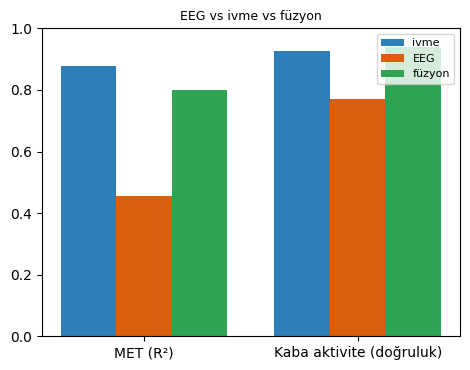

In [ ]:
import matplotlib.pyplot as plt, numpy as np
fig,ax=plt.subplots(figsize=(4.8,3.8)); x=np.arange(2); w=0.26
for k,(lab,col,v) in enumerate([('ivme','#2c7fb8',[0.877,0.928]),('EEG','#d95f0e',[0.456,0.771]),('füzyon','#31a354',[0.800,0.940])]):
    ax.bar(x+(k-1)*w,v,w,label=lab,color=col)
ax.set_xticks(x); ax.set_xticklabels(['MET (R²)','Kaba aktivite (doğruluk)']); ax.set_ylim(0,1); ax.legend(fontsize=8)
ax.set_title('EEG vs ivme vs füzyon',fontsize=9)
plt.tight_layout(); plt.savefig('fig_fusion.png',dpi=300); plt.show()

→ EEG << ivme (MET R² 0.46 vs 0.88); füzyon ivmeyi geçmiyor → EEG ek bilgi katmıyor.

Adım 5: artefakt kapısı — temiz(HSI) vs tüm pencere. ayrım hareket artefaktından mı geliyor?

In [ ]:
Tc,TcCOLS=build_eeg_table(clean_only=True)
_allnan_c=[c for c in TcCOLS if Tc[c].isna().all()]
if _allnan_c:
    Tc=Tc.drop(columns=_allnan_c)
    print("temiz tabloda tamamen boş sütun düşürüldü:",_allnan_c)
Tc['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(Tc['subject'],Tc['activity'])]
print(f"temiz tablo: {len(Tc)} pencere ({len(Tc)/len(T)*100:.0f}% korundu) | özne {Tc['subject'].nunique()}")
mc,_,_=loso_classify(Tc,'activity')
print(f"\naktivite 6-sınıf segment-oyu:  tüm {m['seg_acc']:.3f}  →  temiz {mc['seg_acc']:.3f}")
try:
    print(f"MET MAE:  tüm {metT.iloc[0]['MAE']}  →  temiz {run_reg(Tc,'MET').iloc[0]['MAE']}")
except Exception as e: print("MET(temiz) atlandı:",e)

temiz tablo: 581 pencere (94% korundu) | özne 15

aktivite 6-sınıf segment-oyu:  tüm 0.415  →  temiz 0.450
MET MAE:  tüm 4.055  →  temiz 4.0


→ HSI temizliği ~%94 pencereyi bıraktı, sonuç ~aynı → artefakt sürekli, ani değil.

Özet (kısa).

In [ ]:
print("=== ÖZET ===")
print(f"- Veri: MUSE 4 kanal (TP9/AF7/AF8/TP10), {WIN}s pencere, {T['subject'].nunique()} özne, {len(FCOLS)} özellik")
print(f"- Aktivite (6): pencere acc {m['win_acc']:.3f} / segment-oyu {m['seg_acc']:.3f}")
print(f"- MET en iyi:   {metT.iloc[0]['model']} MAE {metT.iloc[0]['MAE']} SMAPE {metT.iloc[0]['SMAPE']}%")
try: print(f"- EE  en iyi:   {eeT.iloc[0]['model']} MAE {eeT.iloc[0]['MAE']} kcal/dk")
except Exception: pass

=== ÖZET ===
- Veri: MUSE 4 kanal (TP9/AF7/AF8/TP10), 60s pencere, 16 özne, 85 özellik
- Aktivite (6): pencere acc 0.392 / segment-oyu 0.415
- MET en iyi:   XGBoost MAE 4.055 SMAPE 62.521%
- EE  en iyi:   RandomForest MAE 1.502 kcal/dk


Adım 6: EMG-güvenli bantlar (alfa+düşük-beta) + PLV. Neden: delta/theta hareket artefaktını atınca gerçek kortikal sinyal kalıyor mu — Lin 2021.

In [ ]:
from scipy.signal import hilbert
FRONTAL=['AF7','AF8']; TEMPORAL=['TP9','TP10']
PLV_PAIRS=[('AF7','AF8'),('TP9','TP10'),('AF7','TP9'),('AF8','TP10')]
SAFE={'alpha':(8,13),'lowbeta':(14,20)}
def _bp(x,lo,hi):
    b,a=butter(4,[lo/(FS/2),hi/(FS/2)],btype='band'); return filtfilt(b,a,x)
def _plv(x,y):
    d=np.angle(hilbert(x))-np.angle(hilbert(y)); return float(np.abs(np.mean(np.exp(1j*d))))
def _relpow(sig,lo,hi):
    f,P=welch(sig,fs=FS,nperseg=int(min(512,len(sig)))); tot=P[(f>=1)&(f<30)].sum()+1e-12
    return float(P[(f>=lo)&(f<hi)].sum()/tot)
def _abrupt(sig,k=5.0):
    n=int(FS); bad=nb=0
    for i in range(0,len(sig)-n,n):
        s=sig[i:i+n]; z=(s-s.mean())/(s.std()+1e-9); nb+=1; bad+=int(np.max(np.abs(z))>k)
    return bad/max(nb,1)
def build_lin_table(clean_signals=None):
    rows=[]
    for _,r in SI.iterrows():
        pid=r['Participant']; D=get_muse(pid)
        if D is None: continue
        tr=D['tr']; prep=clean_signals[pid] if clean_signals else D['prep']
        for s in activity_segments(r):
            if not s['valid']: continue
            for sl in _win_bounds(tr,s['start'],s['end']):
                if len(sl)<FS*2: continue
                feat={}
                for ch in FRONTAL+TEMPORAL:
                    if prep.get(ch) is None: continue
                    w=prep[ch][sl]
                    for bn,(lo,hi) in SAFE.items(): feat[f'{ch}_{bn}']=_relpow(w,lo,hi)
                    feat[f'{ch}_abrupt']=_abrupt(w)
                for x,y in PLV_PAIRS:
                    if prep.get(x) is None or prep.get(y) is None: continue
                    for bn,(lo,hi) in SAFE.items():
                        feat[f'PLV_{x}{y}_{bn}']=_plv(_bp(prep[x][sl],lo,hi),_bp(prep[y][sl],lo,hi))
                feat.update(MET=s['MET'],activity=s['activity'],
                            coarse=COARSE[s['activity']],subject=pid)
                rows.append(feat)
    T=pd.DataFrame(rows); fc=[c for c in T.columns if c not in META]
    T[fc]=T[fc].replace([np.inf,-np.inf],np.nan)
    return T
TL=build_lin_table(); TL['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(TL['subject'],TL['activity'])]
print(f"EMG-güvenli tablo: {len(TL)} pencere × {len([c for c in TL.columns if c not in META])} özellik")
mL,_,_=loso_classify(TL,'activity'); mLc,_,_=loso_classify(TL,'coarse')
print(f"\nAKTİVİTE — sadece alfa/düşük-beta + PLV (artefakt bandı YOK):")
print(f"  6-sınıf segment-oyu: {mL['seg_acc']:.3f}   (tam set: 0.415)")
print(f"  3-sınıf (rest/cycle/run): {mLc['seg_acc']:.3f}   (tam set: 0.805)")
print("\nMET (EMG-güvenli):"); print(run_reg(TL,'MET')[COLS].head(3).to_string(index=False))
print("\nEE  (EMG-güvenli):"); print(run_reg(TL.dropna(subset=['EE']),'EE')[COLS].head(3).to_string(index=False))

EMG-güvenli tablo: 615 pencere × 20 özellik

AKTİVİTE — sadece alfa/düşük-beta + PLV (artefakt bandı YOK):
  6-sınıf segment-oyu: 0.378   (tam set: 0.415)
  3-sınıf (rest/cycle/run): 0.671   (tam set: 0.805)

MET (EMG-güvenli):
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
         XGBoost 3.832 4.989 0.377     0.574 57.942     5.697 82    16
GradientBoosting 3.841 5.116 0.345     0.563 59.256     5.697 82    16
    RandomForest 4.133 5.280 0.302     0.535 62.715     5.697 82    16

EE  (EMG-güvenli):
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
         XGBoost 1.367 1.822 0.562     0.750 41.727     2.326 76    15
GradientBoosting 1.368 1.842 0.553     0.728 41.444     2.326 76    15
    RandomForest 1.450 1.896 0.526     0.725 44.844     2.326 76    15


→ delta/theta atılınca kaba ayrım 0.805→0.671 → bir kısmı hareket artefaktıydı (ama şansa düşmedi).

Adım 7: IMU regresyon (basit). Neden: cihazın ivmesiyle hareket artefaktını EEG'den çıkarmayı denemek — Ledwidge 2025.

In [ ]:
from numpy.linalg import lstsq
def load_imu(fold,name):
    p=os.path.join(fold,name)
    if not os.path.exists(p): return None,None
    d=_read(p); t=d.iloc[:,0].values
    return t, d.iloc[:,1:4].values.astype(float)
def imu_regress_subject(pid,lags=(0,)):
    D=get_muse(pid); fold=muse_folder(pid)
    if D is None or fold is None: return None
    tr=D['tr']; ta,A=load_imu(fold,'acc.csv'); tg,G=load_imu(fold,'gyro.csv')
    refs=[]
    for (tt,M) in [(ta,A),(tg,G)]:
        if tt is None: continue
        for j in range(M.shape[1]):
            refs.append(np.interp(tr,tt,clean_zeros(M[:,j])))
    if not refs: return D['prep']
    X=np.column_stack(refs); X=(X-X.mean(0))/(X.std(0)+1e-9)
    Xl=np.column_stack([np.roll(X,L,axis=0) for L in lags]+[np.ones(len(X))])
    out={}
    for ch in EEG_CH:
        y=D['prep'].get(ch)
        if y is None: out[ch]=None; continue
        beta,_,_,_=lstsq(Xl,y,rcond=None); out[ch]=y-Xl@beta
    return out
def gait_index(prep,sl):
    idx=[]
    for ch in ['AF7','AF8']:
        if prep.get(ch) is None: continue
        f,P=welch(prep[ch][sl],fs=FS,nperseg=512); tot=P[(f>=1)&(f<30)].sum()+1e-12
        step=P[(f>=2)&(f<3)].sum(); h1=P[(f>=4.5)&(f<5.5)].sum(); h2=P[(f>=7)&(f<8)].sum()
        idx.append((step+h1+h2)/tot)
    return float(np.mean(idx)) if idx else np.nan

print("=== adım-bandı artefakt indeksi (2-3Hz+harmonik pay) — ham vs IMU-temizlenmiş ===")
CLEAN={}
for _,r in SI.iterrows():
    pid=r['Participant']; c=imu_regress_subject(pid)
    if c is not None: CLEAN[pid]=c
print(f"IMU-temizlenmiş özne sayısı: {len(CLEAN)}")
if CLEAN:
    for pid in list(CLEAN)[:3]:
        D=get_muse(pid); raw=D['prep']; cl=CLEAN[pid]
        for nm in ['Sit','Run2']:
            seg=[s for s in activity_segments(SI[SI.Participant==pid].iloc[0]) if s['activity']==nm]
            if not seg or not seg[0]['valid']: continue
            wb=_win_bounds(D['tr'],seg[0]['start'],seg[0]['end'])
            if not wb: continue
            gr=np.nanmean([gait_index(raw,sl) for sl in wb]); gc=np.nanmean([gait_index(cl,sl) for sl in wb])
            print(f"  {pid} {nm:5}: adım-payı ham {gr:.3f} → temiz {gc:.3f}")
    TLc=build_lin_table(clean_signals=CLEAN); TLc['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(TLc['subject'],TLc['activity'])]
    mIMU,_,_=loso_classify(TLc,'coarse')
    print(f"\nIMU-temizlenmiş + EMG-güvenli → 3-sınıf segment-oyu: {mIMU['seg_acc']:.3f}")
else:
    print("acc.csv/gyro.csv bulunamadı — MUSE klasör yolunu kontrol et")

=== adım-bandı artefakt indeksi (2-3Hz+harmonik pay) — ham vs IMU-temizlenmiş ===
IMU-temizlenmiş özne sayısı: 16
  P01 Sit  : adım-payı ham 0.264 → temiz 0.264
  P01 Run2 : adım-payı ham 0.361 → temiz 0.357
  P03 Sit  : adım-payı ham 0.261 → temiz 0.261
  P03 Run2 : adım-payı ham 0.337 → temiz 0.330
  P04 Sit  : adım-payı ham 0.333 → temiz 0.334

IMU-temizlenmiş + EMG-güvenli → 3-sınıf segment-oyu: 0.720


→ adım-bandı oynamadı → basit doğrusal IMU regresyonu yetersiz.

Adım 8: PLV + PLI + coherence (çok bant). Neden: bağlantısallık gerçek mi — PLI/COH hacim-iletimine dirençli — Vinck 2011 / Lin 2021.

In [ ]:
from scipy.signal import hilbert, coherence
CONN_BANDS={'alpha':(8,13),'lowbeta':(14,20),'highbeta':(20,30)}
CONN_PAIRS=[('AF7','AF8'),('TP9','TP10'),('AF7','TP9'),('AF8','TP10')]
def _bpf(x,lo,hi):
    b,a=butter(4,[lo/(FS/2),hi/(FS/2)],btype='band'); return filtfilt(b,a,x)
def _plv(x,y): d=np.angle(hilbert(x))-np.angle(hilbert(y)); return float(np.abs(np.mean(np.exp(1j*d))))
def _pli(x,y): d=np.angle(hilbert(x))-np.angle(hilbert(y)); return float(np.abs(np.mean(np.sign(np.sin(d)))))
def _coh(x,y,lo,hi):
    f,Cxy=coherence(x,y,fs=FS,nperseg=256); m=(f>=lo)&(f<hi)
    return float(np.mean(Cxy[m])) if m.any() else np.nan
def _relpow(sig,lo,hi):
    f,P=welch(sig,fs=FS,nperseg=int(min(512,len(sig)))); tot=P[(f>=8)&(f<30)].sum()+1e-12
    return float(P[(f>=lo)&(f<hi)].sum()/tot)
def build_conn_table(clean_signals=None):
    rows=[]
    for _,r in SI.iterrows():
        pid=r['Participant']; D=get_muse(pid)
        if D is None: continue
        tr=D['tr']; prep=clean_signals[pid] if clean_signals else D['prep']
        for s in activity_segments(r):
            if not s['valid']: continue
            for sl in _win_bounds(tr,s['start'],s['end']):
                if len(sl)<FS*2: continue
                feat={}
                for ch in ['TP9','AF7','AF8','TP10']:
                    if prep.get(ch) is None: continue
                    for bn,(lo,hi) in CONN_BANDS.items(): feat[f'{ch}_{bn}']=_relpow(prep[ch][sl],lo,hi)
                for x,y in CONN_PAIRS:
                    if prep.get(x) is None or prep.get(y) is None: continue
                    for bn,(lo,hi) in CONN_BANDS.items():
                        xb,yb=_bpf(prep[x][sl],lo,hi),_bpf(prep[y][sl],lo,hi)
                        feat[f'PLV_{x}{y}_{bn}']=_plv(xb,yb)
                        feat[f'PLI_{x}{y}_{bn}']=_pli(xb,yb)
                        feat[f'COH_{x}{y}_{bn}']=_coh(prep[x][sl],prep[y][sl],lo,hi)
                feat.update(MET=s['MET'],activity=s['activity'],coarse=COARSE[s['activity']],subject=pid)
                rows.append(feat)
    T=pd.DataFrame(rows); fc=[c for c in T.columns if c not in META]
    T[fc]=T[fc].replace([np.inf,-np.inf],np.nan); return T
TC=build_conn_table(); TC['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(TC['subject'],TC['activity'])]
print(f"bağlantısallık tablosu: {len(TC)} pencere × {len([c for c in TC.columns if c not in META])} özellik")
mc,_,_=loso_classify(TC,'coarse'); m6,_,_=loso_classify(TC,'activity')
print(f"\nAKTİVİTE: 3-sınıf {mc['seg_acc']:.3f} (v1 tam 0.805 / EMG-güvenli 0.671) | 6-sınıf {m6['seg_acc']:.3f}")
print("\nMET:"); print(run_reg(TC,'MET')[COLS].head(3).to_string(index=False))
eeC=run_reg(TC.dropna(subset=['EE']),'EE'); print("\nEE:"); print(eeC[COLS].head(3).to_string(index=False))

bağlantısallık tablosu: 615 pencere × 48 özellik

AKTİVİTE: 3-sınıf 0.756 (v1 tam 0.805 / EMG-güvenli 0.671) | 6-sınıf 0.390

MET:
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
GradientBoosting 3.772 4.964 0.383     0.568 57.090     5.697 82    16
         XGBoost 3.906 5.068 0.357     0.541 58.167     5.697 82    16
    RandomForest 3.911 5.042 0.363     0.535 59.577     5.697 82    16

EE:
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
    RandomForest 1.455 2.023 0.460     0.683 42.052     2.326 76    15
         XGBoost 1.588 2.190 0.368     0.639 45.288     2.326 76    15
GradientBoosting 1.641 2.271 0.320     0.610 47.259     2.326 76    15


→ PLV yükseliyor ama PLI (zero-lag dirençli) düz → PLV kısmen hacim-iletimi olabilir.

Adım 8b: EE özellik önemi (aile). Neden: EE'yi güç mü, bağlantısallık mı sürüyor?

In [ ]:
from sklearn.ensemble import RandomForestRegressor
d=TC.dropna(subset=['EE']).reset_index(drop=True); cols=[c for c in d.columns if c not in META and pd.api.types.is_numeric_dtype(d[c])]
imp=np.zeros(len(cols))
for tr,te in LeaveOneGroupOut().split(d[cols],d['EE'],d['subject']):
    rf=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=200,random_state=0,n_jobs=-1))
    rf.fit(d[cols].iloc[tr],d['EE'].iloc[tr]); imp+=rf.named_steps['randomforestregressor'].feature_importances_
imp/=d['subject'].nunique(); S=pd.Series(imp,index=cols).sort_values(ascending=False)
print("EE'de en etkili 12 özellik:"); print(S.head(12).round(4).to_string())
fam=lambda p: 'PLV' if p.startswith('PLV') else 'PLI' if p.startswith('PLI') else 'COH' if p.startswith('COH') else 'güç'
byfam=S.groupby([fam(c) for c in S.index]).sum().sort_values(ascending=False)
print("\naile bazında toplam önem (EE):"); print(byfam.round(3).to_string())

EE'de en etkili 12 özellik:
TP9_highbeta           0.4517
TP9_alpha              0.0927
TP10_highbeta          0.0772
PLV_AF7AF8_alpha       0.0357
COH_AF8TP10_alpha      0.0323
AF8_highbeta           0.0226
AF7_highbeta           0.0173
AF7_lowbeta            0.0161
AF8_alpha              0.0150
PLV_AF7AF8_highbeta    0.0149
PLV_AF7AF8_lowbeta     0.0147
COH_AF8TP10_lowbeta    0.0132

aile bazında toplam önem (EE):
güç    0.738
PLV    0.111
COH    0.100
PLI    0.050


→ EE'yi %74 güç sürüyor; bağlantısallık minör, TP9 baskın.

Adım 9: IMU regresyon (gecikmeli ±3 + nonlineer). basit regresyona adil şans; iCanClean mantığı — Ledwidge 2025.

In [ ]:
from numpy.linalg import lstsq
def load_imu(fold,name):
    p=os.path.join(fold,name)
    if not os.path.exists(p): return None,None
    d=_read(p); return d.iloc[:,0].values, d.iloc[:,1:4].values.astype(float)
def imu_regress_rich(pid,lags=(-3,-2,-1,0,1,2,3)):
    D=get_muse(pid); fold=muse_folder(pid)
    if D is None or fold is None: return None
    tr=D['tr']; base=[]
    for nm in ['acc.csv','gyro.csv']:
        tt,M=load_imu(fold,nm)
        if tt is None: continue
        for j in range(M.shape[1]):
            s=np.interp(tr,tt,clean_zeros(M[:,j])); base.append(s)
    if not base: return D['prep']
    B=np.column_stack(base); B=(B-B.mean(0))/(B.std(0)+1e-9)
    nl=[np.abs(B),B**2]
    mag=np.sqrt(np.sum(B[:,:3]**2,axis=1,keepdims=True)) if B.shape[1]>=3 else np.zeros((len(B),1))
    Xbase=np.column_stack([B]+nl+[mag])
    Xl=np.column_stack([np.roll(Xbase,L,axis=0) for L in lags]+[np.ones(len(Xbase))])
    out={}
    for ch in EEG_CH:
        y=D['prep'].get(ch)
        if y is None: out[ch]=None; continue
        beta,_,_,_=lstsq(Xl,y,rcond=None); out[ch]=y-Xl@beta
    return out
def gait_index(prep,sl):
    v=[]
    for ch in ['AF7','AF8']:
        if prep.get(ch) is None: continue
        f,P=welch(prep[ch][sl],fs=FS,nperseg=512); tot=P[(f>=1)&(f<30)].sum()+1e-12
        v.append((P[(f>=2)&(f<3)].sum()+P[(f>=4.5)&(f<5.5)].sum()+P[(f>=7)&(f<8)].sum())/tot)
    return float(np.mean(v)) if v else np.nan
CLEAN2={};
for _,r in SI.iterrows():
    c=imu_regress_rich(r['Participant'])
    if c is not None: CLEAN2[r['Participant']]=c
print(f"zengin IMU-temizlenmiş özne: {len(CLEAN2)}")
gr=[]; gc=[]
for _,r in SI.iterrows():
    pid=r['Participant']
    if pid not in CLEAN2: continue
    seg=[s for s in activity_segments(r) if s['activity']=='Run2' and s['valid']]
    if not seg: continue
    wb=_win_bounds(get_muse(pid)['tr'],seg[0]['start'],seg[0]['end'])
    if not wb: continue
    gr.append(np.nanmean([gait_index(get_muse(pid)['prep'],sl) for sl in wb]))
    gc.append(np.nanmean([gait_index(CLEAN2[pid],sl) for sl in wb]))
print(f"Run2 adım-bandı payı (kohort ort.): ham {np.nanmean(gr):.3f} → temiz {np.nanmean(gc):.3f} "
      f"(azalma {(1-np.nanmean(gc)/np.nanmean(gr))*100:.1f}%)")
TCc=build_conn_table(clean_signals=CLEAN2); TCc['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(TCc['subject'],TCc['activity'])]
mc2,_,_=loso_classify(TCc,'coarse')
print(f"IMU-temizlenmiş + bağlantısallık → 3-sınıf: {mc2['seg_acc']:.3f}  (temizsiz: {mc['seg_acc']:.3f})")

zengin IMU-temizlenmiş özne: 16
Run2 adım-bandı payı (kohort ort.): ham 0.401 → temiz 0.357 (azalma 11.1%)
IMU-temizlenmiş + bağlantısallık → 3-sınıf: 0.744  (temizsiz: 0.756)


→ zengin IMU adım-bandını ~%11 azalttı ama ayrım korundu → kalıntı mekanik değil (EMG).

Adım 10: EE ablasyonu (temporal/highbeta çıkar). EE sinyali kortekste mi, temporal EMG'de mi — Goncharova 2003.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
d=TC.dropna(subset=['EE']).reset_index(drop=True)
allc=[c for c in d.columns if c not in META and pd.api.types.is_numeric_dtype(d[c])]
def ee_perf(cols):
    y=d['EE'].values; yh=np.full(len(d),np.nan)
    for tr,te in LeaveOneGroupOut().split(d[cols],y,d['subject']):
        m=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=300,random_state=0,n_jobs=-1))
        m.fit(d[cols].iloc[tr],y[tr]); yh[te]=m.predict(d[cols].iloc[te])
    seg=pd.DataFrame({'s':d['subject'],'a':d['activity'],'y':y,'p':yh}).groupby(['s','a']).agg(y=('y','first'),p=('p','mean'))
    return mean_absolute_error(seg['y'],seg['p']), r2_score(seg['y'],seg['p'])
frontal_only=[c for c in allc if 'TP9' not in c and 'TP10' not in c]
no_hb=[c for c in allc if 'highbeta' not in c]
no_temp_hb=[c for c in allc if not (('TP9' in c or 'TP10' in c) and 'highbeta' in c)]
print("=== EE ablasyonu (temporal / yüksek-beta çıkarınca sinyal yaşıyor mu?) ===")
for nm,cols in [('tüm özellikler',allc),('frontal-only (TP9/TP10 YOK)',frontal_only),
                ('highbeta YOK',no_hb),('temporal-highbeta YOK',no_temp_hb)]:
    mae,r2=ee_perf(cols); print(f"  {nm:28}: MAE {mae:.3f}  R2 {r2:.3f}  ({len(cols)} öz.)")
print("\n=== TP9_highbeta ↔ EE: özne-içi mi, özneler-arası mı? ===")
if 'TP9_highbeta' in d.columns:
    b=d.groupby('subject').agg(x=('TP9_highbeta','mean'),y=('EE','mean'))
    rb=pearsonr(b['x'],b['y'])[0]
    xw=d['TP9_highbeta']-d.groupby('subject')['TP9_highbeta'].transform('mean')
    yw=d['EE']-d.groupby('subject')['EE'].transform('mean')
    rw=pearsonr(xw,yw)[0]
    print(f"  özneler-ARASI r = {rb:+.3f}   |   özne-İÇİ r = {rw:+.3f}")

=== EE ablasyonu (temporal / yüksek-beta çıkarınca sinyal yaşıyor mu?) ===
  tüm özellikler              : MAE 1.455  R2 0.460  (48 öz.)
  frontal-only (TP9/TP10 YOK) : MAE 1.958  R2 0.128  (15 öz.)
  highbeta YOK                : MAE 1.456  R2 0.454  (32 öz.)
  temporal-highbeta YOK       : MAE 1.454  R2 0.453  (37 öz.)

=== TP9_highbeta ↔ EE: özne-içi mi, özneler-arası mı? ===
  özneler-ARASI r = -0.617   |   özne-İÇİ r = -0.751


→ şekil: EE ablasyonu

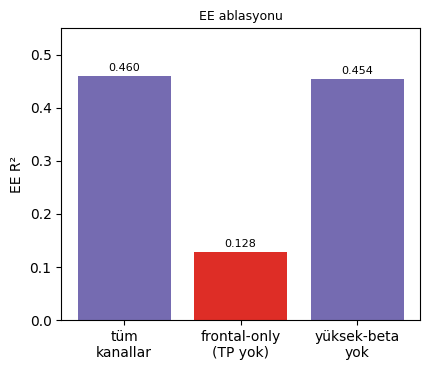

In [ ]:
import matplotlib.pyplot as plt
vals=[0.460,0.128,0.454]; fig,ax=plt.subplots(figsize=(4.4,3.8))
ax.bar(['tüm\nkanallar','frontal-only\n(TP yok)','yüksek-beta\nyok'],vals,color=['#756bb1','#de2d26','#756bb1'])
ax.set_ylim(0,0.55); ax.set_ylabel('EE R²')
for i,v in enumerate(vals): ax.text(i,v+0.01,f"{v:.3f}",ha='center',fontsize=8)
ax.set_title('EE ablasyonu',fontsize=9)
plt.tight_layout(); plt.savefig('fig_ablation.png',dpi=300); plt.show()

→ temporal çıkınca EE R² 0.46→0.13 çöküyor → sinyal kortekste değil (temporal EMG); özne-içi TP9↔EE r=−0.75.

Adım 11: HR mediasyonu (Zephyr ECG-HR). temporal EEG sinyali kalp hızıyla mı açıklanıyor — kulak-arkası kardiyak (Mandic 2024), HR→EE (O'Driscoll 2020).

In [ ]:
def zephyr_hr(pid):
    for f in glob.glob(os.path.join(DATA_ROOT,'*','ZEPHYR','*Summary*.csv')):
        if 'P%02d'%int(''.join(filter(str.isdigit,f.split(os.sep)[-3])))!=pid: continue
        z=pd.read_csv(f); z.columns=z.columns.str.strip()
        tcol=next((c for c in ['Time','Timestamp','time'] if c in z.columns),None)
        hcol=next((c for c in ['HR','HR[bpm]','HeartRate','Heart Rate'] if c in z.columns),None)
        if tcol is None or hcol is None: continue
        t=pd.to_datetime(z[tcol],errors='coerce',dayfirst=True)
        if t.notna().mean()<0.5: continue
        u=(t.dt.tz_localize('UTC') if t.dt.tz is None else t).map(lambda x:x.timestamp()).values
        h=pd.to_numeric(z[hcol],errors='coerce').values
        m=np.isfinite(u)&np.isfinite(h)&(h>0)
        if m.sum()>10: return u[m],h[m]
    return None,None

HR_MAP={}
for _,r in SI.iterrows():
    pid=r['Participant']; u,h=zephyr_hr(pid)
    if u is None:
        path=find_vo2(pid)
        if path is not None:
            ref=to_unix(r['Start_Sit']); start=parse_details_start(pid,ref)
            used=ref if (start is None or abs(start-ref)>MAX_OFF) else start
            v=pd.read_csv(path); v.columns=v.columns.str.strip()
            hc=next((c for c in ['HR[bpm]','HR','HeartRate'] if c in v.columns),None)
            if hc is not None:
                vv=v[pd.to_numeric(v[hc],errors='coerce')>0]; u=vo2_unix(vv,used); h=vv[hc].values
    if u is None: continue
    for s in activity_segments(r):
        w=h[(u>=s['start'])&(u<s['end'])]
        HR_MAP[(pid,s['activity'])]=float(np.mean(w)) if len(w) else np.nan

nsub=len({k[0] for k,v in HR_MAP.items() if v==v})
print(f"HR'li özne: {nsub}  | HR'li segment: {sum(v==v for v in HR_MAP.values())}")
d=TC.dropna(subset=['EE']).reset_index(drop=True)
d['HR']=[HR_MAP.get((s,a),np.nan) for s,a in zip(d['subject'],d['activity'])]
d=d.dropna(subset=['HR']).reset_index(drop=True)
print(f"HR+EE'li pencere: {len(d)} | özne: {d['subject'].nunique()}")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr
tempcols=[c for c in d.columns if (c.startswith('TP9_') or c.startswith('TP10_')) and pd.api.types.is_numeric_dtype(d[c])]

def loso_pred(X,y,g,n_est=300,seed=0):
    yh=np.full(len(y),np.nan)
    for tr,te in LeaveOneGroupOut().split(X,y,g):
        m=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=n_est,random_state=seed,n_jobs=-1))
        m.fit(X.iloc[tr],y[tr]); yh[te]=m.predict(X.iloc[te])
    return yh

def segR2(y,yh,sub,act):
    s=pd.DataFrame({'s':sub,'a':act,'y':y,'p':yh}).groupby(['s','a']).agg(y=('y','first'),p=('p','mean'))
    return r2_score(s['y'],s['p']), mean_absolute_error(s['y'],s['p'])

gain_obs=np.nan; p_val=np.nan; r2_re=np.nan
if d['subject'].nunique()>=5:
    yh_hr =loso_pred(d[['HR']],d['EE'].values,d['subject']);            r2_hr,mae_hr =segR2(d['EE'].values,yh_hr ,d['subject'],d['activity'])
    yh_ee =loso_pred(d[tempcols],d['EE'].values,d['subject']);          r2_ee,mae_ee =segR2(d['EE'].values,yh_ee ,d['subject'],d['activity'])
    yh_bo =loso_pred(d[['HR']+tempcols],d['EE'].values,d['subject']);   r2_bo,mae_bo =segR2(d['EE'].values,yh_bo ,d['subject'],d['activity'])
    res=np.full(len(d),np.nan)
    for tr,te in LeaveOneGroupOut().split(d[['HR']],d['EE'],d['subject']):
        lm=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=200,random_state=0,n_jobs=-1))
        lm.fit(d[['HR']].iloc[tr],d['EE'].values[tr]); res[te]=d['EE'].values[te]-lm.predict(d[['HR']].iloc[te])
    yh_re =loso_pred(d[tempcols],res,d['subject']);                     r2_re,_      =segR2(res,yh_re,d['subject'],d['activity'])
    gain_obs = r2_bo - r2_hr

    print(f"\nEE (segment R2, LOSO, {d['subject'].nunique()} özne):")
    print(f"  yalnız HR (Zephyr ECG)        : R2 {r2_hr:6.3f}  MAE {mae_hr:.3f}")
    print(f"  yalnız temporal-EEG           : R2 {r2_ee:6.3f}  MAE {mae_ee:.3f}")
    print(f"  HR + temporal-EEG             : R2 {r2_bo:6.3f}  MAE {mae_bo:.3f}  (HR üstüne EEG katkısı: {gain_obs:+.3f})")
    print(f"  temporal-EEG -> EE|HR kalıntısı: R2 {r2_re:6.3f}")

    def permute_within_subject(y,subj,rng):
        y2=y.copy()
        for s in pd.unique(subj):
            idx=np.where(subj.values==s)[0]
            y2[idx]=rng.permutation(y[idx])
        return y2

    N_PERM=30
    rng=np.random.default_rng(0)
    null_gain=[]
    y_true=d['EE'].values
    for k in range(N_PERM):
        y_perm=permute_within_subject(y_true,d['subject'],rng)
        yh_hr_p=loso_pred(d[['HR']],y_perm,d['subject'],n_est=100,seed=k)
        yh_bo_p=loso_pred(d[['HR']+tempcols],y_perm,d['subject'],n_est=100,seed=k)
        r2_hr_p,_=segR2(y_perm,yh_hr_p,d['subject'],d['activity'])
        r2_bo_p,_=segR2(y_perm,yh_bo_p,d['subject'],d['activity'])
        null_gain.append(r2_bo_p-r2_hr_p)
    null_gain=np.array(null_gain)
    p_val=float((null_gain>=gain_obs).mean())
    print(f"\n  [sağlamlık — özne-içi blok permütasyon] boş dağılım ortalaması {null_gain.mean():+.3f} "
          f"(SD {null_gain.std():.3f}) | gözlenen kazanç {gain_obs:+.3f} | ampirik p={p_val:.3f}")
    if p_val<0.05:
        pass
    else:
        print(f"  -> SONUÇ: gözlenen kazanç ({gain_obs:+.3f}), hiçbir gerçek ilişki olmasa bile aynı büyüklükte")
        print(f"     ortaya çıkan şans-düzeyi kazançtan (ort. {null_gain.mean():+.3f}) istatistiksel olarak AYIRT EDİLEMİYOR (p={p_val:.2f}).")
else:
    print(f"\n[!] Sadece {d['subject'].nunique()} özne HR'lı — LOSO zayıf. Zephyr HR okunmadıysa Summary kolon başlığını gönder.")

print("\nözne-içi korelasyonlar:")
for feat in [c for c in ['TP9_alpha','TP9_highbeta','TP10_alpha'] if c in d.columns]:
    xw=d[feat]-d.groupby('subject')[feat].transform('mean')
    hw=d['HR']-d.groupby('subject')['HR'].transform('mean')
    ew=d['EE']-d.groupby('subject')['EE'].transform('mean')
    print(f"  {feat:14}: ↔HR r={pearsonr(xw.fillna(0),hw)[0]:+.3f} | ↔EE r={pearsonr(xw.fillna(0),ew)[0]:+.3f}")



HR'li özne: 17  | HR'li segment: 95
HR+EE'li pencere: 567 | özne: 15

EE (segment R2, LOSO, 15 özne):
  yalnız HR (Zephyr ECG)        : R2  0.536  MAE 1.420
  yalnız temporal-EEG           : R2  0.510  MAE 1.395
  HR + temporal-EEG             : R2  0.685  MAE 1.131  (HR üstüne EEG katkısı: +0.149)
  temporal-EEG -> EE|HR kalıntısı: R2 -0.237

  [sağlamlık — özne-içi blok permütasyon] boş dağılım ortalaması +0.168 (SD 0.113) | gözlenen kazanç +0.149 | ampirik p=0.600
  -> SONUÇ: gözlenen kazanç (+0.149), hiçbir gerçek ilişki olmasa bile aynı büyüklükte
     ortaya çıkan şans-düzeyi kazançtan (ort. +0.168) istatistiksel olarak AYIRT EDİLEMİYOR (p=0.60).

özne-içi korelasyonlar:
  TP9_alpha     : ↔HR r=+0.758 | ↔EE r=+0.739
  TP9_highbeta  : ↔HR r=-0.756 | ↔EE r=-0.751
  TP10_alpha    : ↔HR r=+0.716 | ↔EE r=+0.712


→ şekil: HR mediasyonu + özne-içi korelasyon

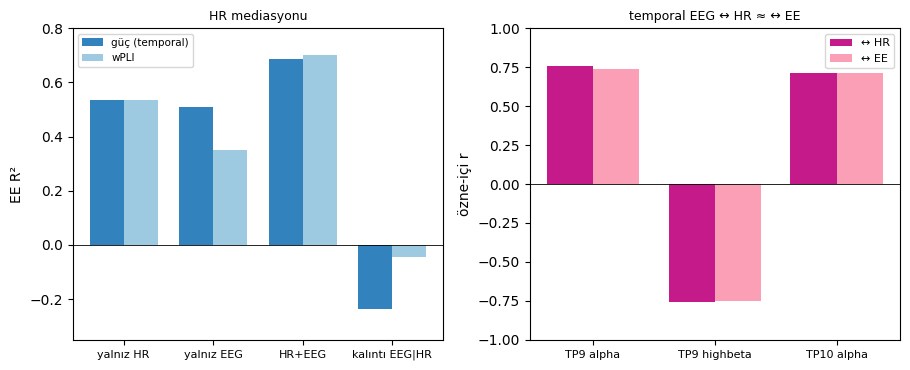

In [ ]:
import matplotlib.pyplot as plt, numpy as np
fig,axs=plt.subplots(1,2,figsize=(9.2,3.8))
x=np.arange(4); w=0.38
axs[0].bar(x-w/2,[0.536,0.510,0.685,-0.237],w,label='güç (temporal)',color='#3182bd')
axs[0].bar(x+w/2,[0.536,0.349,0.703,-0.043],w,label='wPLI',color='#9ecae1')
axs[0].axhline(0,color='k',lw=0.6); axs[0].set_xticks(x); axs[0].set_xticklabels(['yalnız HR','yalnız EEG','HR+EEG','kalıntı EEG|HR'],fontsize=8)
axs[0].set_ylabel('EE R²'); axs[0].legend(fontsize=7.5); axs[0].set_ylim(-0.35,0.8); axs[0].set_title('HR mediasyonu',fontsize=9)
x=np.arange(3); w=0.38
axs[1].bar(x-w/2,[0.758,-0.756,0.716],w,label='↔ HR',color='#c51b8a'); axs[1].bar(x+w/2,[0.739,-0.751,0.712],w,label='↔ EE',color='#fa9fb5')
axs[1].axhline(0,color='k',lw=0.6); axs[1].set_xticks(x); axs[1].set_xticklabels(['TP9 alpha','TP9 highbeta','TP10 alpha'],fontsize=8); axs[1].set_ylim(-1,1)
axs[1].set_ylabel('özne-içi r'); axs[1].legend(fontsize=8); axs[1].set_title('temporal EEG ↔ HR ≈ ↔ EE',fontsize=9)
plt.tight_layout(); plt.savefig('fig_hr_mediation.png',dpi=300); plt.show()

→ temporal-EEG ≈ gerçek HR kadar iyi; kalıntı≈0, permütasyon p=0.60 → EE sinyali HR ile açıklanıyor (kardiyak, brain-heart), kortikal değil.

Adım 12: wPLI (artefakt-dirençli bağlantısallık). en iyi ölçüde bile kortikal bağlantısallık var mı — Vinck 2011.

In [ ]:
def wpli(x,y,lo,hi,seg=2.0):
    n=int(seg*FS); w=np.hanning(n); cs=[]
    for i in range(0,len(x)-n,n//2):
        X=np.fft.rfft(x[i:i+n]*w); Y=np.fft.rfft(y[i:i+n]*w); cs.append(X*np.conj(Y))
    if not cs: return np.nan
    cs=np.array(cs); f=np.fft.rfftfreq(n,1/FS); m=(f>=lo)&(f<hi)
    im=np.imag(cs[:,m]); num=np.abs(np.mean(im,axis=0)); den=np.mean(np.abs(im),axis=0)+1e-12
    return float(np.mean(num/den))
WB={'alpha':(8,13),'lowbeta':(14,20),'highbeta':(20,30)}
WPAIRS=[('AF7','AF8'),('TP9','TP10'),('AF7','TP9'),('AF8','TP10')]
rows=[]
for _,r in SI.iterrows():
    pid=r['Participant']; D=get_muse(pid)
    if D is None: continue
    tr=D['tr']; prep=D['prep']
    for s in activity_segments(r):
        if not s['valid']: continue
        for sl in _win_bounds(tr,s['start'],s['end']):
            if len(sl)<FS*2: continue
            feat={}
            for x,y in WPAIRS:
                if prep.get(x) is None or prep.get(y) is None: continue
                for bn,(lo,hi) in WB.items(): feat[f'wPLI_{x}{y}_{bn}']=wpli(prep[x][sl],prep[y][sl],lo,hi)
            feat.update(activity=s['activity'],coarse=COARSE[s['activity']],MET=s['MET'],subject=pid)
            rows.append(feat)
W=pd.DataFrame(rows); W['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(W['subject'],W['activity'])]
wcols=[c for c in W.columns if c.startswith('wPLI')]
print(f"wPLI tablosu: {len(W)} pencere × {len(wcols)} wPLI özelliği")

mc,_,_=loso_classify(W,'coarse'); m6,_,_=loso_classify(W,'activity')
print(f"\nYALNIZ wPLI ile: 3-sınıf {mc['seg_acc']:.3f} (şans 0.33) | 6-sınıf {m6['seg_acc']:.3f} (şans 0.17)")
print("EE (yalnız wPLI):"); print(run_reg(W.dropna(subset=['EE']),'EE')[COLS].head(2).to_string(index=False))

from sklearn.ensemble import RandomForestRegressor
TCw=TC.merge(W[['subject','activity']+wcols].groupby(['subject','activity']).mean().reset_index(),
             on=['subject','activity'],how='left')
d=TCw.dropna(subset=['EE']).reset_index(drop=True)
cols=[c for c in d.columns if c not in META and pd.api.types.is_numeric_dtype(d[c])]
imp=np.zeros(len(cols))
for tr,te in LeaveOneGroupOut().split(d[cols],d['EE'],d['subject']):
    rf=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=200,random_state=0,n_jobs=-1))
    rf.fit(d[cols].iloc[tr],d['EE'].iloc[tr]); imp+=rf.named_steps['randomforestregressor'].feature_importances_
imp/=d['subject'].nunique(); S=pd.Series(imp,index=cols)
fam=lambda p:'wPLI' if p.startswith('wPLI') else 'PLV' if p.startswith('PLV') else 'PLI' if p.startswith('PLI') else 'COH' if p.startswith('COH') else 'güç'
print("\nEE önem — aile bazında (wPLI dahil):"); print(S.groupby([fam(c) for c in S.index]).sum().sort_values(ascending=False).round(3).to_string())

wPLI tablosu: 615 pencere × 12 wPLI özelliği

YALNIZ wPLI ile: 3-sınıf 0.585 (şans 0.33) | 6-sınıf 0.207 (şans 0.17)
EE (yalnız wPLI):
           model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
        SVR(RBF) 1.671 2.214 0.354     0.639 50.728     2.326 76    15
GradientBoosting 1.793 2.183 0.372     0.609 56.274     2.326 76    15

EE önem — aile bazında (wPLI dahil):
güç     0.619
wPLI    0.301
PLV     0.043
COH     0.029
PLI     0.008


→ wPLI zayıf sinyal taşıyor; 4 kanalla kortikal/periferik ayrılamıyor.

→ şekil: EE özellik önemi (aile)

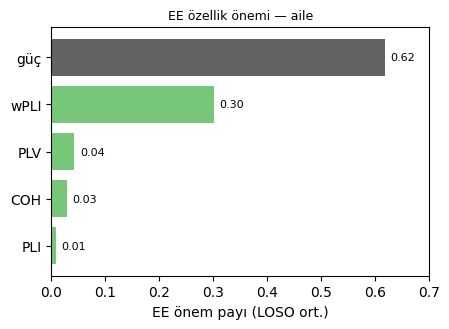

In [ ]:
import matplotlib.pyplot as plt
fam=['güç','wPLI','PLV','COH','PLI']; imp=[0.619,0.301,0.043,0.029,0.008]
fig,ax=plt.subplots(figsize=(4.6,3.4))
ax.barh(fam[::-1],imp[::-1],color=['#636363','#78c679','#78c679','#78c679','#78c679'][::-1])
for i,v in enumerate(imp[::-1]): ax.text(v+0.01,i,f"{v:.2f}",va='center',fontsize=8)
ax.set_xlim(0,0.7); ax.set_xlabel('EE önem payı (LOSO ort.)'); ax.set_title('EE özellik önemi — aile',fontsize=9)
plt.tight_layout(); plt.savefig('fig_importance.png',dpi=300); plt.show()

→ güç baskın; bağlantısallık (PLV/PLI/COH/wPLI) toplam ~%16.

Adım 12b: wPLI frontal vs temporal.  wPLI sinyali frontal (kortikal) mi, temporal (periferik) mi?

In [ ]:
wcols=[c for c in W.columns if c.startswith('wPLI')]
front_only=[c for c in wcols if 'AF7AF8' in c]
temporal  =[c for c in wcols if ('TP9' in c or 'TP10' in c)]
def ee_coarse(cols):
    d=W.dropna(subset=['EE']).reset_index(drop=True)
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import r2_score, mean_absolute_error
    y=d['EE'].values; yh=np.full(len(d),np.nan)
    for tr,te in LeaveOneGroupOut().split(d[cols],y,d['subject']):
        m=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=300,random_state=0,n_jobs=-1))
        m.fit(d[cols].iloc[tr],y[tr]); yh[te]=m.predict(d[cols].iloc[te])
    seg=pd.DataFrame({'s':d['subject'],'a':d['activity'],'y':y,'p':yh}).groupby(['s','a']).agg(y=('y','first'),p=('p','mean'))
    r2=r2_score(seg['y'],seg['p']); mae=mean_absolute_error(seg['y'],seg['p'])
    mc,_,_=loso_classify(W.assign(**{c:W[c] for c in cols})[cols+['activity','coarse','subject','MET']].dropna(),'coarse')
    return r2,mae,mc['seg_acc']
for nm,cols in [('yalnız FRONTAL (AF7-AF8)',front_only),('TEMPORAL-içeren çiftler',temporal),('tüm wPLI',wcols)]:
    if not cols: print(f"  {nm}: (özellik yok)"); continue
    r2,mae,ca=ee_coarse(cols)
    print(f"  {nm:26}: EE R2 {r2:+.3f} MAE {mae:.3f} | kaba-aktivite {ca:.3f}  ({len(cols)} özellik)")

  yalnız FRONTAL (AF7-AF8)  : EE R2 +0.227 MAE 2.043 | kaba-aktivite 0.573  (3 özellik)
  TEMPORAL-içeren çiftler   : EE R2 +0.298 MAE 1.904 | kaba-aktivite 0.512  (9 özellik)
  tüm wPLI                  : EE R2 +0.349 MAE 1.857 | kaba-aktivite 0.585  (12 özellik)


→ frontal wPLI de çökmüyor → 4 kanalla kaynak ayrımı net değil (sınırlama).

Adım 12c: wPLI HR mediasyonu. bağlantısallık da HR ile mi açıklanıyor?

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
d=W.dropna(subset=['EE']).reset_index(drop=True)
d['HR']=[HR_MAP.get((s,a),np.nan) for s,a in zip(d['subject'],d['activity'])]
d=d.dropna(subset=['HR']).reset_index(drop=True)
wcols=[c for c in d.columns if c.startswith('wPLI')]
print(f"HR+EE+wPLI'li pencere: {len(d)} | özne: {d['subject'].nunique()}")
def loso_pred(X,y,g):
    yh=np.full(len(y),np.nan)
    for tr,te in LeaveOneGroupOut().split(X,y,g):
        m=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=300,random_state=0,n_jobs=-1))
        m.fit(X.iloc[tr],y[tr]); yh[te]=m.predict(X.iloc[te])
    return yh
def segR2(y,yh,s,a):
    df=pd.DataFrame({'s':s,'a':a,'y':y,'p':yh}).groupby(['s','a']).agg(y=('y','first'),p=('p','mean'))
    return r2_score(df['y'],df['p']), mean_absolute_error(df['y'],df['p'])
if d['subject'].nunique()>=5:
    y=d['EE'].values
    r2_hr,mae_hr=segR2(y,loso_pred(d[['HR']],y,d['subject']),d['subject'],d['activity'])
    r2_w ,mae_w =segR2(y,loso_pred(d[wcols],y,d['subject']),d['subject'],d['activity'])
    r2_b ,_     =segR2(y,loso_pred(d[['HR']+wcols],y,d['subject']),d['subject'],d['activity'])
    res=np.full(len(d),np.nan)
    for tr,te in LeaveOneGroupOut().split(d[['HR']],y,d['subject']):
        lm=make_pipeline(SimpleImputer(strategy='median'),RandomForestRegressor(n_estimators=200,random_state=0,n_jobs=-1))
        lm.fit(d[['HR']].iloc[tr],y[tr]); res[te]=y[te]-lm.predict(d[['HR']].iloc[te])
    r2_re,_=segR2(res,loso_pred(d[wcols],res,d['subject']),d['subject'],d['activity'])
    print(f"\nEE (segment R2, LOSO, {d['subject'].nunique()} özne):")
    print(f"  yalnız HR           : R2 {r2_hr:+.3f}  MAE {mae_hr:.3f}")
    print(f"  yalnız wPLI         : R2 {r2_w:+.3f}  MAE {mae_w:.3f}")
    print(f"  HR + wPLI           : R2 {r2_b:+.3f}   (HR üstüne wPLI katkısı: {r2_b-r2_hr:+.3f})")
    print(f"  wPLI -> EE|HR kalıntısı: R2 {r2_re:+.3f}")
else:
    print("[!] yetersiz özne")

HR+EE+wPLI'li pencere: 567 | özne: 15

EE (segment R2, LOSO, 15 özne):
  yalnız HR           : R2 +0.536  MAE 1.420
  yalnız wPLI         : R2 +0.349  MAE 1.857
  HR + wPLI           : R2 +0.703   (HR üstüne wPLI katkısı: +0.168)
  wPLI -> EE|HR kalıntısı: R2 -0.043


→ wPLI de HR'ı geçmiyor (kalıntı −0.04) → bağlantısallık da HR ile açıklanıyor.

# Sonuç
- Aktivite: 6-sınıf 0.415 · kaba 3-sınıf 0.805 (hatalar tip-içi)
- MET: MAE 4.055 · R² 0.398 · SMAPE %62.5
- EE: en iyi MAE 1.367 · R² 0.562
- EE ablasyonu (R²): tüm 0.460 · frontal-only 0.128 · highbeta-yok 0.454
- HR mediasyonu (EE R²): HR 0.536 · EEG 0.510 · HR+EEG 0.685 · kalıntı −0.237 · permütasyon p=0.60
- wPLI mediasyonu (EE R²): wPLI 0.349 · HR+wPLI 0.703 · kalıntı −0.043
- EEG vs ivme (MET R²): 0.456 vs 0.877 · füzyon 0.800
- EE özellik önemi: güç 0.62 · wPLI 0.30 · PLV 0.04 · COH 0.03 · PLI 0.01
- Özne-içi: TP9↔HR +0.758 ≈ TP9↔EE +0.739